/var/folders/24/f9mpl0gx1rs5tb1xb_z_cqmw0000gn/T/ipykernel_82337/229230215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


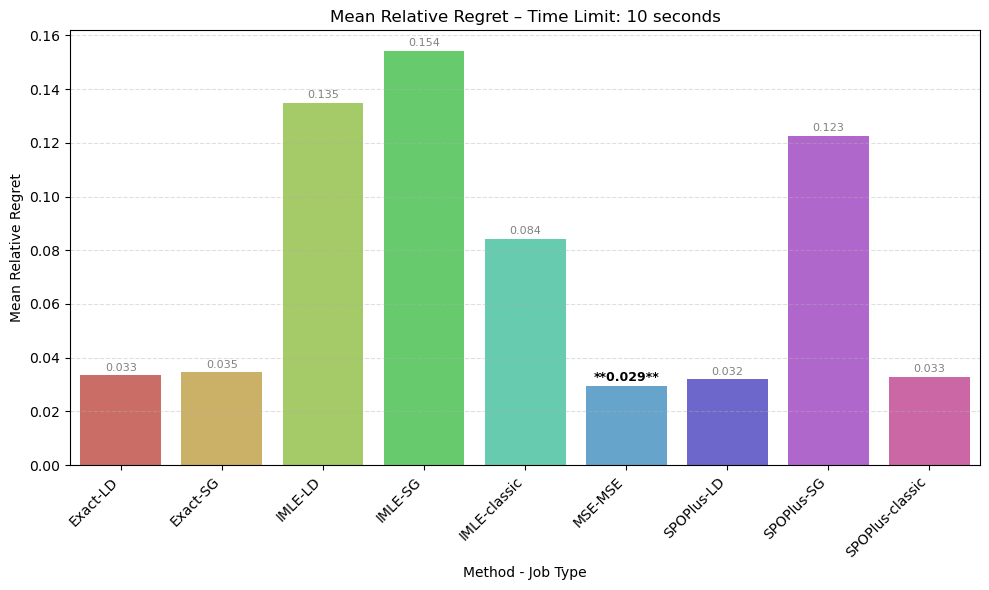

/var/folders/24/f9mpl0gx1rs5tb1xb_z_cqmw0000gn/T/ipykernel_82337/229230215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


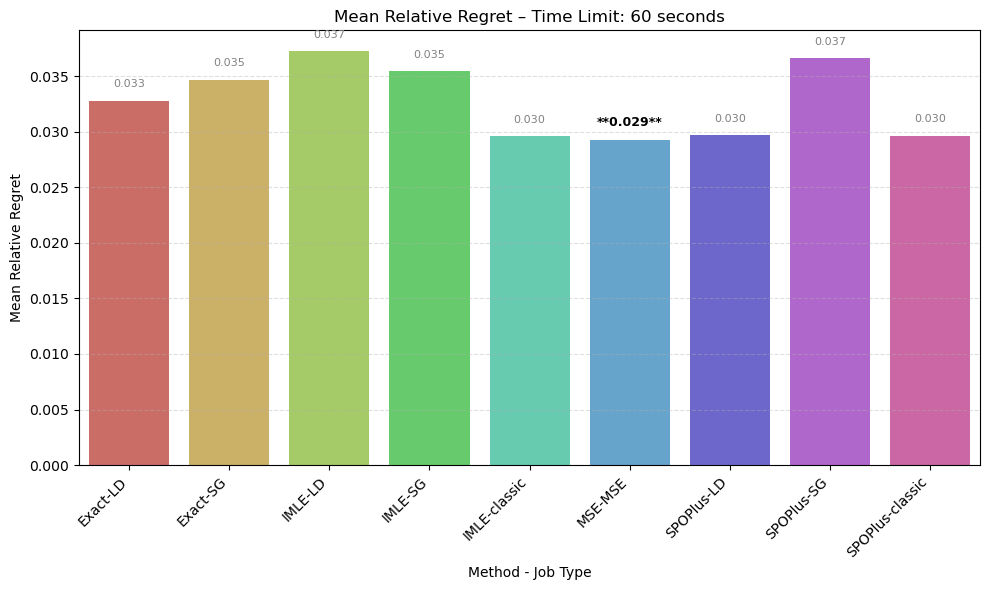

/var/folders/24/f9mpl0gx1rs5tb1xb_z_cqmw0000gn/T/ipykernel_82337/229230215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


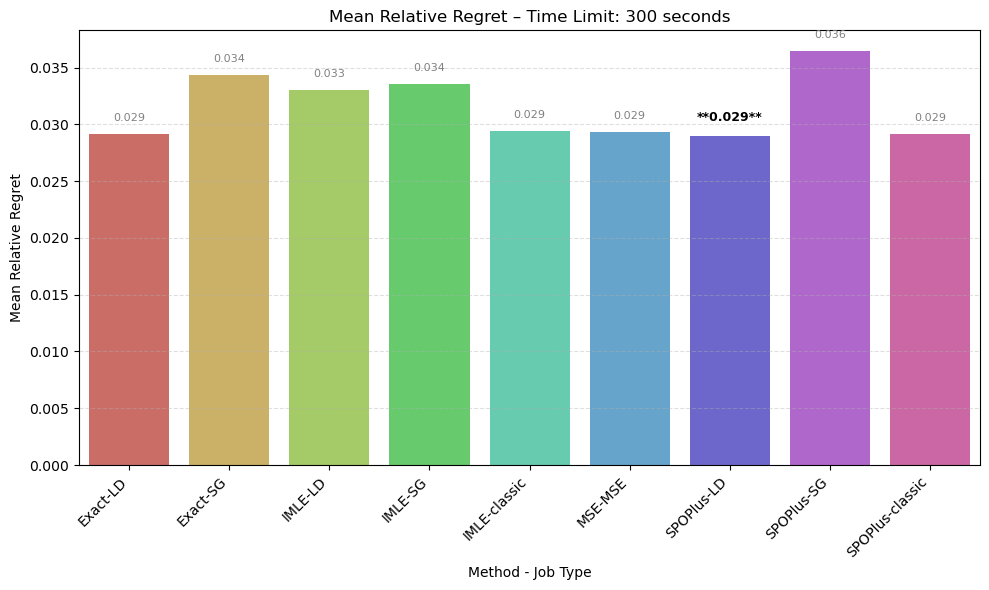

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv("portfolio/results_temps_deg4.csv")

# Créer colonne method-jobtype
df["method_jobtype"] = df["method"] + "-" + df["jobtype"].astype(str)

# Grouper
grouped = df.groupby(["time limit", "method_jobtype"])["mean_relat_test"].mean().reset_index()

# Liste des time limits
time_limits = sorted(grouped["time limit"].unique())

# Palette
palette = sns.color_palette("hls", len(grouped["method_jobtype"].unique()))

for t in time_limits:
    subset = grouped[grouped["time limit"] == t].copy()
    
    # Identifier la meilleure (plus bas regret)
    best_idx = subset["mean_relat_test"].idxmin()
    best_row = subset.loc[best_idx]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=subset,
        x="method_jobtype",
        y="mean_relat_test",
        palette=palette
    )
    
    # Titre
    plt.title(f"Mean Relative Regret – Time Limit: {int(t)} seconds")
    plt.xlabel("Method - Job Type")
    plt.ylabel("Mean Relative Regret")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    
    # Annoter la meilleure barre
    for i, bar in enumerate(ax.patches):
        val = subset.iloc[i]["mean_relat_test"]
        label = f"{val:.3f}"
        if i == list(subset.index).index(best_idx):
            # En gras pour la meilleure
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"**{label}**",
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='black'
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                label,
                ha='center',
                va='bottom',
                fontsize=8,
                color='gray'
            )
    
    plt.tight_layout()
    plt.show()

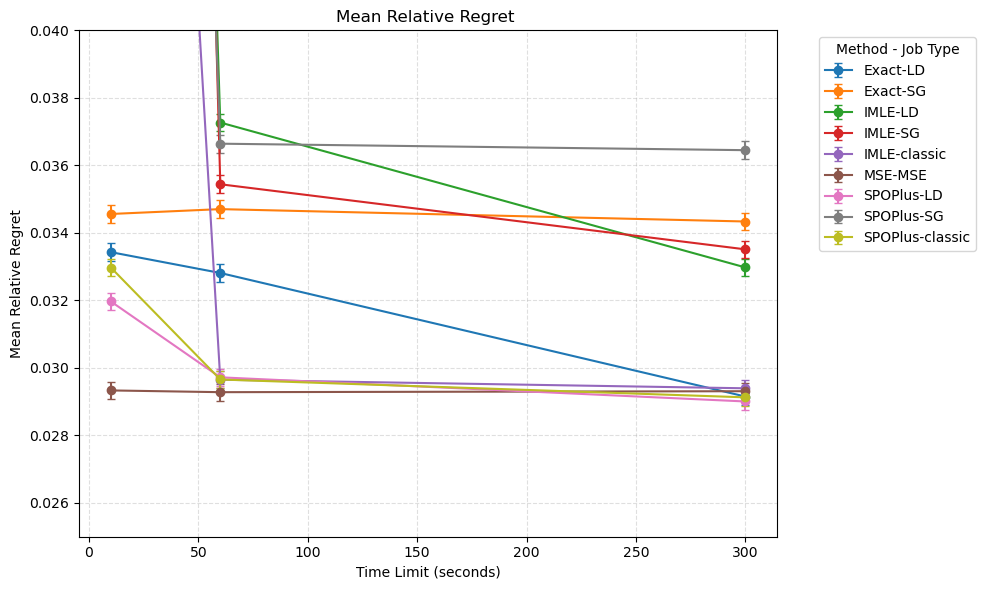

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger les données
df = pd.read_csv("portfolio/results_temps_deg4.csv")

# Créer identifiant méthode-type
df["method_jobtype"] = df["method"] + "-" + df["jobtype"].astype(str)

# Calcul de l'intervalle de confiance 95 %
df["ci95"] = 1.96 * df["std_relat_test"] / np.sqrt(10000)

# Moyenne et CI groupées
grouped = df.groupby(["method_jobtype", "time limit"]).agg(
    mean=("mean_relat_test", "mean"),
    ci95=("ci95", "mean")
).reset_index()

# Palette
palette = sns.color_palette("tab10", n_colors=grouped["method_jobtype"].nunique())

# Tracer les courbes avec barres d'erreur
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped.groupby("method_jobtype")):
    group = group.sort_values("time limit")
    plt.errorbar(
        group["time limit"],
        group["mean"],
        yerr=group["ci95"],
        label=name,
        marker='o',
        capsize=3,
        linestyle='-',
        color=palette[i]
    )

plt.title("Mean Relative Regret ")
plt.xlabel("Time Limit (seconds)")
plt.ylabel("Mean Relative Regret")
plt.ylim(0.025, 0.04)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()